# Week 3 — Data Parallelism & Synchronous SGD

**Distributed Systems for Machine Learning**

---

Data parallelism is the workhorse of distributed training. The recipe:

1. **Replicate** the model on every worker.
2. **Shard** each mini-batch: worker $i$ gets a different slice of the data.
3. Each worker computes a **local gradient** on its slice.
4. **All-reduce** the gradients (Week 2!) so every worker has the *average* gradient.
5. Every worker applies the **same** update → replicas stay identical.

This week we:

- Prove that averaging gradients over sharded data is **mathematically identical** to one big-batch gradient.
- Build a real (tiny) data-parallel trainer in NumPy and run it with $P$ simulated workers.
- Study the **large-batch problem**: why naive scaling hurts accuracy, and the **linear scaling rule** + **warmup** that fix it.
- Measure **strong vs weak scaling** and where communication eats the gains.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(3)
plt.rcParams["figure.figsize"]=(9,4.5); plt.rcParams["axes.grid"]=True

## 1. Why averaging local gradients is exact

For a loss that is a **mean over samples**, $L(\theta)=\frac1B\sum_{i=1}^B \ell_i(\theta)$, the gradient is linear in the per-sample gradients. Split the batch across $P$ workers, each holding $B/P$ samples:

$$\nabla L = \frac1B\sum_{i=1}^B \nabla\ell_i = \frac1P\sum_{p=1}^P\underbrace{\left(\frac{P}{B}\sum_{i\in S_p}\nabla\ell_i\right)}_{\text{local gradient }g_p}= \frac1P\sum_p g_p.$$

So **averaging the local gradients reproduces the full-batch gradient exactly** — no approximation. That single fact is what makes synchronous data parallelism *correct*. Let's verify numerically.


In [2]:
# tiny linear-regression problem: loss = mean (x.w - y)^2
B, d = 800, 10
X = np.random.randn(B, d); w_true = np.random.randn(d)
y = X @ w_true + 0.1*np.random.randn(B)
w = np.zeros(d)

def full_grad(w):
    r = X @ w - y
    return (2.0/B) * (X.T @ r)

def local_grad(w, idx):
    Xs, ys = X[idx], y[idx]
    bs = len(idx)
    r = Xs @ w - ys
    return (2.0/bs) * (Xs.T @ r)

P = 4
shards = np.array_split(np.arange(B), P)
g_avg = np.mean([local_grad(w, s) for s in shards], axis=0)
print("max |full_grad - avg(local_grads)| =", np.max(np.abs(full_grad(w)-g_avg)))
print("=> identical up to float error: synchronous data parallelism is exact.")

max |full_grad - avg(local_grads)| = 6.661338147750939e-16
=> identical up to float error: synchronous data parallelism is exact.


## 2. A data-parallel trainer with simulated workers

Each "worker" is just a slice of the data. We loop: local grads → all-reduce (average) → identical update. Because the update is identical, we only need to track **one** parameter vector — but we *count communication* honestly with the cost model from Week 2.

P=1: final MSE=0.0099  simulated comm time=0.000 ms
P=2: final MSE=0.0099  simulated comm time=0.400 ms
P=4: final MSE=0.0099  simulated comm time=1.200 ms
P=8: final MSE=0.0099  simulated comm time=2.800 ms


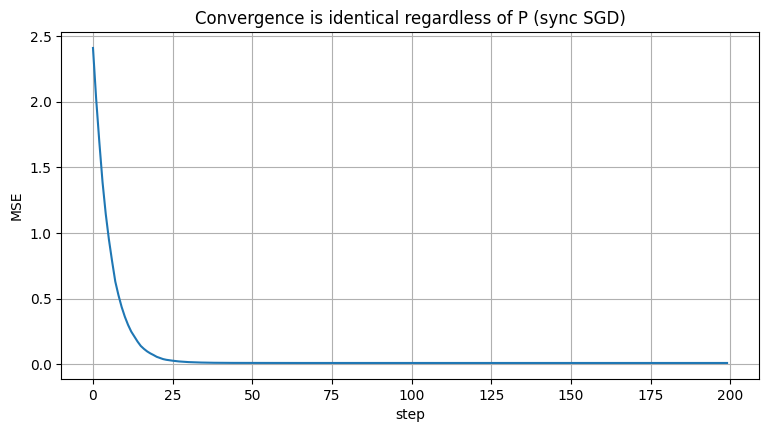

In [3]:
def ring_allreduce_cost(n_bytes, P, alpha=1e-6, beta=1/100e9):
    return 2*(P-1)*alpha + 2*(P-1)/P*n_bytes*beta

def train_data_parallel(P, steps=200, lr=0.05, batch=256):
    w = np.zeros(d); comm_time = 0.0; losses=[]
    grad_bytes = d*8  # float64
    for t in range(steps):
        idx = np.random.randint(0, B, size=batch)
        local = np.array_split(idx, P)
        g = np.mean([local_grad(w, s) for s in local], axis=0)   # = all-reduced grad
        comm_time += ring_allreduce_cost(grad_bytes, P)
        w -= lr * g
        r = X @ w - y; losses.append(float(np.mean(r*r)))
    return w, losses, comm_time

for P in (1,2,4,8):
    w,L,ct = train_data_parallel(P)
    print(f"P={P}: final MSE={L[-1]:.4f}  simulated comm time={ct*1e3:.3f} ms")
plt.plot(train_data_parallel(4)[1]); plt.xlabel("step"); plt.ylabel("MSE")
plt.title("Convergence is identical regardless of P (sync SGD)"); plt.show()

## 3. The large-batch problem & the linear scaling rule

When you add workers, the *effective batch size* grows ($B_{\text{eff}} = P\times B_{\text{local}}$). A larger batch gives a **lower-variance** gradient — so you can afford a **larger learning rate**. The empirical **linear scaling rule** (Goyal et al., 2017):

> When the batch size is multiplied by $k$, multiply the learning rate by $k$ — combined with a few epochs of **warmup**.

Too-large LR without warmup diverges; too-small LR wastes the larger batch. Let's see both failure modes on our toy problem (we add gradient noise to mimic stochasticity).

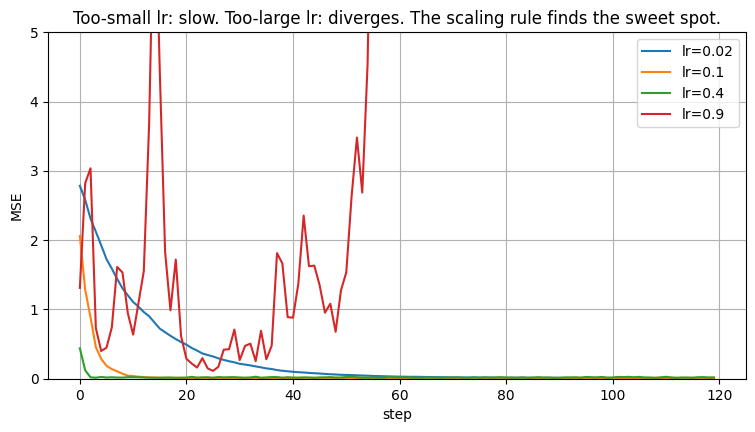

In [4]:
def train_lr(lr, steps=120, batch=64, noise=0.5):
    w=np.zeros(d); L=[]
    for t in range(steps):
        idx=np.random.randint(0,B,batch)
        g=local_grad(w,idx)+noise*np.random.randn(d)/np.sqrt(batch)
        w-=lr*g
        r=X@w-y; L.append(float(np.mean(r*r)))
        if not np.isfinite(L[-1]): break
    return L

fig,ax=plt.subplots()
for lr in [0.02,0.1,0.4,0.9]:
    L=train_lr(lr); ax.plot(L,label=f"lr={lr}")
ax.set_ylim(0,5); ax.set_xlabel("step"); ax.set_ylabel("MSE")
ax.set_title("Too-small lr: slow. Too-large lr: diverges. The scaling rule finds the sweet spot.")
ax.legend(); plt.show()

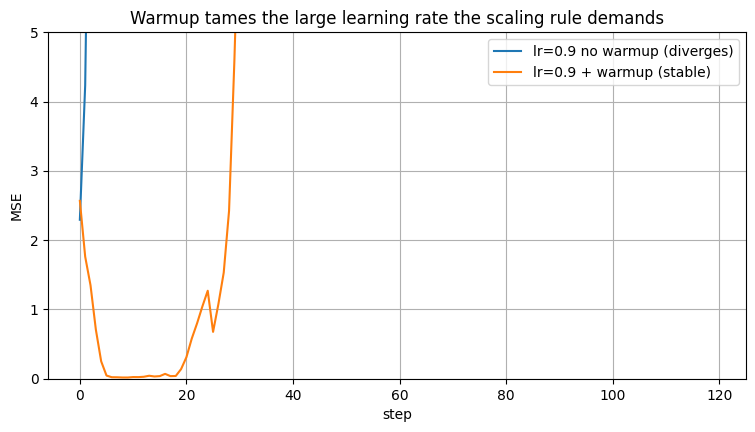

In [5]:
def warmup_lr(t, base_lr, warmup=20):
    return base_lr * min(1.0, (t+1)/warmup)

def train_warmup(base_lr, steps=120, batch=64, noise=0.5, warmup=20):
    w=np.zeros(d); L=[]
    for t in range(steps):
        idx=np.random.randint(0,B,batch)
        g=local_grad(w,idx)+noise*np.random.randn(d)/np.sqrt(batch)
        w-=warmup_lr(t,base_lr,warmup)*g
        r=X@w-y; L.append(float(np.mean(r*r)))
        if not np.isfinite(L[-1]): break
    return L

plt.plot(train_lr(0.9),label="lr=0.9 no warmup (diverges)")
plt.plot(train_warmup(0.9),label="lr=0.9 + warmup (stable)")
plt.ylim(0,5); plt.legend(); plt.xlabel("step"); plt.ylabel("MSE")
plt.title("Warmup tames the large learning rate the scaling rule demands"); plt.show()

## 4. Strong vs weak scaling, and the communication wall

- **Strong scaling:** fix the *global* batch, add workers → each does less compute, but communication cost per step is unchanged → eventually comm dominates (Amdahl, Week 1).
- **Weak scaling:** grow the global batch with workers → compute per worker constant → efficiency holds much longer (Gustafson).

We model step time as `max(compute, comm)` with perfect overlap, then `compute + (1-overlap)*comm` for realistic partial overlap.

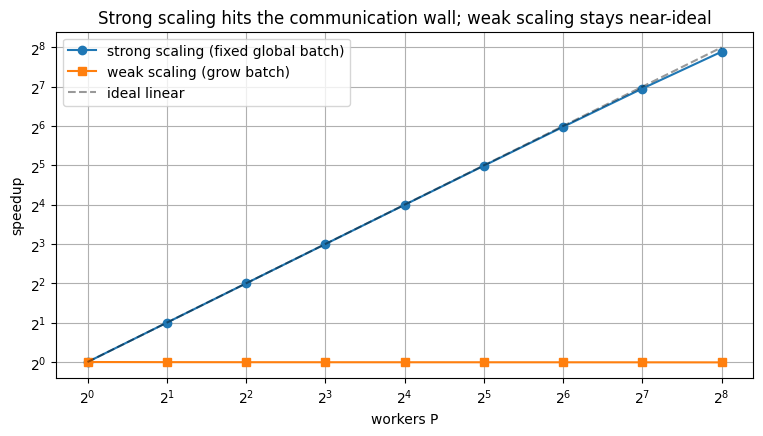

In [6]:
flops_per_sample = 1.0           # arbitrary unit
device_rate = 1e6                # samples/sec equivalent
grad_bytes = 50*2**20            # 50 MB gradient (bigger model)

def step_time(P, global_batch, weak=False, overlap=0.8):
    local_batch = global_batch/P if not weak else global_batch  # weak: per-worker fixed
    compute = local_batch*flops_per_sample/device_rate
    comm = ring_allreduce_cost(grad_bytes, P)
    return compute + (1-overlap)*comm, compute, comm

Ps=[1,2,4,8,16,32,64,128,256]
strong=[1/step_time(p, 1_000_000)[0] for p in Ps]
weak  =[1/step_time(p, 50_000, weak=True)[0] for p in Ps]
strong=np.array(strong)/strong[0]; weak=np.array(weak)/weak[0]
plt.plot(Ps,strong,"o-",label="strong scaling (fixed global batch)")
plt.plot(Ps,weak,"s-",label="weak scaling (grow batch)")
plt.plot(Ps,Ps,"k--",alpha=.4,label="ideal linear")
plt.xscale("log",base=2); plt.yscale("log",base=2)
plt.xlabel("workers P"); plt.ylabel("speedup"); plt.legend()
plt.title("Strong scaling hits the communication wall; weak scaling stays near-ideal"); plt.show()

## Exercises

1. **Exactness with weights.** Show averaging stays exact when workers hold *unequal* shard sizes if you weight each local gradient by its sample count. Implement the weighted all-reduce.
2. **Gradient accumulation.** Implement accumulating $k$ micro-batch gradients before one all-reduce. Show it gives the same result as a $k\times$ batch but with $1/k$ the communication. When is this strictly better than more workers?
3. **Scaling-rule experiment.** Sweep $P\in\{1,2,4,8\}$ with `lr = base*P` and warmup, on the noisy problem. Plot final MSE vs $P$; confirm the rule keeps accuracy roughly constant while naive constant-lr degrades it.
4. **Communication wall.** For the 50 MB gradient, find the $P$ at which comm equals compute in strong scaling. How does increasing `overlap` push that wall out?
5. **Bucketing revisited.** Combine Week 1's bucketing with this trainer: instead of one 50 MB all-reduce, do it as the model trains layer-by-layer, overlapping backward compute with comm. Estimate the speedup.
